In [1]:
import pickle as pkl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import signal
from scipy.signal import welch
from scipy.signal import stft
%matplotlib inline

import mne

In [2]:
labels_twente = []
labels_geneva = []
data_twente = []
data_geneva = []

In [3]:
twente = []
for n in range(1, 23): 
    s = ''
    if n < 10:
        s += '0'
    s += str(n)
    twente.append(s)
print(twente)

['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22']


In [4]:
geneva = []
for n in range(23, 33): 
    s = ''
    s += str(n)
    geneva.append(s)
print(geneva)

['23', '24', '25', '26', '27', '28', '29', '30', '31', '32']


In [5]:
for i in twente:
    file = 'data_preprocessed_python/s' + i + '.dat'
    with open(file, 'rb') as f:
        x = pkl.load(f, encoding='latin1')
    labels_twente.append(x['labels'])
    data_twente.append(x['data'])


In [6]:
for i in geneva:
    file = 'data_preprocessed_python/s' + i + '.dat'
    with open(file, 'rb') as f:
        x = pkl.load(f, encoding='latin1')
    labels_geneva.append(x['labels'])
    data_geneva.append(x['data'])

In [7]:
labels_twente = np.array(labels_twente)
data_twente = np.array(data_twente)
labels_twente = labels_twente.flatten()
data_twente = data_twente.flatten()
labels_twente = labels_twente.reshape(880,4)
data_twente = data_twente.reshape(880,40,8064)


In [8]:
labels_geneva = np.array(labels_geneva)
data_geneva = np.array(data_geneva)
labels_geneva = labels_geneva.flatten()
data_geneva = data_geneva.flatten()
labels_geneva = labels_geneva.reshape(400,4)
data_geneva = data_geneva.reshape(400,40,8064)


In [9]:
labels = np.concatenate((labels_twente, labels_geneva))
data = np.concatenate((data_twente, data_geneva))

In [10]:
df_labels = pd.DataFrame({'Valence': labels[:,0], 'Arousal': labels[:,1], 'Dominance': labels[:,2], 'Liking': labels[:,3]})

In [11]:
df_labels.head()

,Valence,Arousal,Dominance,Liking
0,7.71,7.60,6.90,7.83
1,8.10,7.31,7.28,8.47
2,8.58,7.54,9.00,7.08
3,4.94,6.01,6.12,8.06
4,6.96,3.92,7.19,6.05


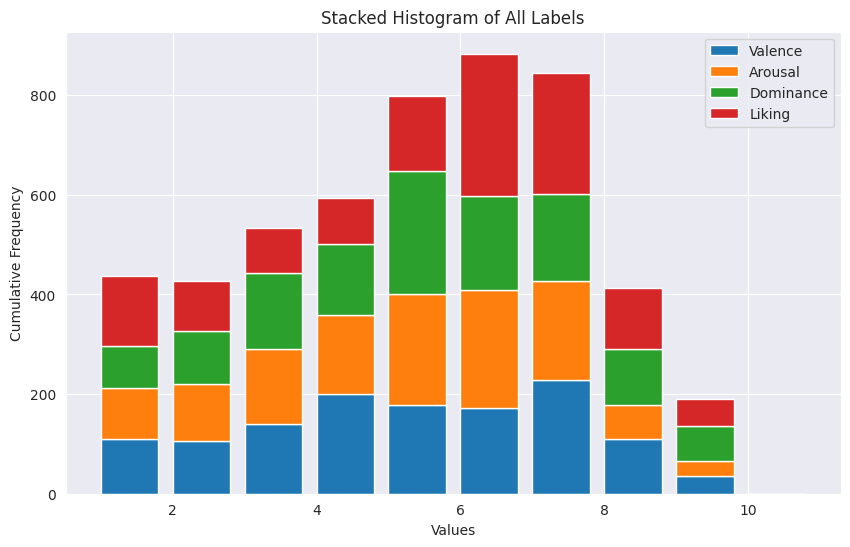

In [12]:
cumulative_freq = np.zeros(10)
plt.figure(figsize=(10, 6))

for column in df_labels.columns:
    hist, bins = np.histogram(df_labels[column], bins=10, range=(1, 11))
    plt.bar(bins[:-1], hist, width=0.8, align='edge', bottom=cumulative_freq, label=column)
    cumulative_freq += hist

plt.xlabel('Values')
plt.ylabel('Cumulative Frequency')
plt.title('Stacked Histogram of All Labels')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
df_hahv = df_labels[(df_labels['Valence'] >= np.median(labels[:,0])) & (df_labels['Arousal'] >= np.median(labels[:,1]))]
df_lahv = df_labels[(df_labels['Valence'] >= np.median(labels[:,0])) & (df_labels['Arousal'] < np.median(labels[:,1]))]
df_halv = df_labels[(df_labels['Valence'] < np.median(labels[:,0])) & (df_labels['Arousal'] >= np.median(labels[:,1]))]
df_lalv = df_labels[(df_labels['Valence'] < np.median(labels[:,0])) & (df_labels['Arousal'] < np.median(labels[:,1]))]

In [14]:
print("Median Valence (to divide positive and negative): ", df_labels['Valence'].median())
print("Median Arousal (to divide high and low): ", df_labels['Arousal'].median())

Median Valence (to divide positive and negative):  5.04
Median Arousal (to divide high and low):  5.23


In [15]:
print("Positive Valence:", str(len(df_hahv) + len(df_lahv)))
print("Negative Valence:", str(len(df_halv) + len(df_lalv)))
print("High Arousal:", str(len(df_hahv) + len(df_halv)))
print("Low Arousal:", str(len(df_lahv) + len(df_lalv)))

Positive Valence: 680
Negative Valence: 600
High Arousal: 640
Low Arousal: 640


In [16]:
print("High Arousal Positive Valence (HAPV):", str(len(df_hahv)))
print("Low Arousal Positive Valence (LAHV):", str(len(df_lahv)))
print("High Arousal Negative Valence (HALV):", str(len(df_halv)))
print("Low Arousal Negative Valence (LALV):", str(len(df_lalv)))

High Arousal Positive Valence (HAPV): 358
Low Arousal Positive Valence (LAHV): 322
High Arousal Negative Valence (HALV): 282
Low Arousal Negative Valence (LALV): 318


In [17]:
print("HAHV")
print("Valence:", "Mean", np.round(df_hahv['Valence'].mean(),2), "STD", np.round(df_hahv['Valence'].std(),2))
print("Arousal:", "Mean", np.round(df_hahv['Arousal'].mean(),2), "STD", np.round(df_hahv['Arousal'].std(),2))
print()
print("LAHV:")
print("Valence:", "Mean", np.round(df_lahv['Valence'].mean(),2), "STD", np.round(df_lahv['Valence'].std(),2))
print("Arousal:", "Mean", np.round(df_lahv['Arousal'].mean(),2), "STD", np.round(df_lahv['Arousal'].std(),2))
print()
print("HALV:")
print("Valence:", "Mean", np.round(df_halv['Valence'].mean(),2), "STD", np.round(df_halv['Valence'].std(),2))
print("Arousal:", "Mean", np.round(df_halv['Arousal'].mean(),2), "STD", np.round(df_halv['Arousal'].std(),2))
print()
print("LALV:")
print("Valence:", "Mean", np.round(df_lalv['Valence'].mean(),2), "STD", np.round(df_lalv['Valence'].std(),2))
print("Arousal:", "Mean", np.round(df_lalv['Arousal'].mean(),2), "STD", np.round(df_lalv['Arousal'].std(),2))

HAHV
Valence: Mean 7.23 STD 1.03
Arousal: Mean 6.87 STD 0.87

LAHV:
Valence: Mean 6.59 STD 1.1
Arousal: Mean 3.83 STD 1.17

HALV:
Valence: Mean 3.11 STD 1.25
Arousal: Mean 6.8 STD 0.97

LALV:
Valence: Mean 3.59 STD 1.19
Arousal: Mean 3.12 STD 1.32


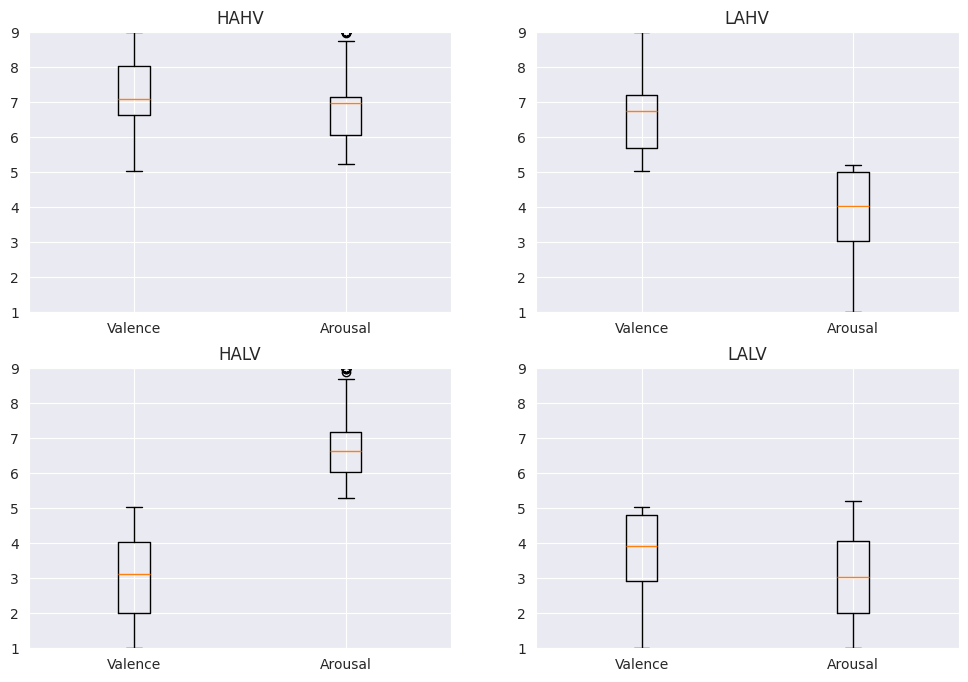

In [18]:
fig, axs = plt.subplots(2, 2, figsize=(12,8))

axs[0,0].set_title("HAHV")
axs[0,0].set_ylim(1, 9)
axs[0,0].boxplot([df_hahv['Valence'], df_hahv['Arousal']], labels=['Valence','Arousal'])

axs[0,1].set_title("LAHV")
axs[0,1].set_ylim(1, 9)
axs[0,1].boxplot([df_lahv['Valence'], df_lahv['Arousal']], labels=['Valence','Arousal'])

axs[1,0].set_title("HALV")
axs[1,0].set_ylim(1, 9)
axs[1,0].boxplot([df_halv['Valence'], df_halv['Arousal']], labels=['Valence','Arousal'])

axs[1,1].set_title("LALV")
axs[1,1].set_ylim(1, 9)
axs[1,1].boxplot([df_lalv['Valence'], df_lalv['Arousal']], labels=['Valence','Arousal']);

In [19]:
eeg_channels = np.array(["Fp1", "AF3", "F3", "F7", "FC5", "FC1", "C3", "T7", "CP5", "CP1", "P3", "P7", "PO3", "O1", "Oz", "Pz", "Fp2", "AF4", "Fz", "F4", "F8", "FC6", "FC2", "Cz", "C4", "T8", "CP6", "CP2", "P4", "P8", "PO4", "O2"])
peripheral_channels = np.array(["hEOG", "vEOG", "zEMG", "tEMG", "GSR", "Respiration belt", "Plethysmograph", "Temperature"])

In [20]:
eeg_data = []
for i in range (len(data)):
  for j in range (len(eeg_channels)):
    eeg_data.append(data[i,j])
eeg_data = np.reshape(eeg_data, (len(data), len(eeg_channels), len(data[0,0])))
print(eeg_data.shape)

(1280, 32, 8064)


In [21]:
print(data[1,1])

[ 9.49186875 12.58977035 10.57402679 ...  6.0339949   9.06874552
  8.74021419]


In [22]:
peripheral_data = []
for i in range (len(data)):
  for j in range (32,len(data[0])):
    peripheral_data.append(data[i,j])
peripheral_data = np.reshape(peripheral_data, (len(data), len(peripheral_channels), len(data[0,0])))
print(peripheral_data.shape)

(1280, 8, 8064)


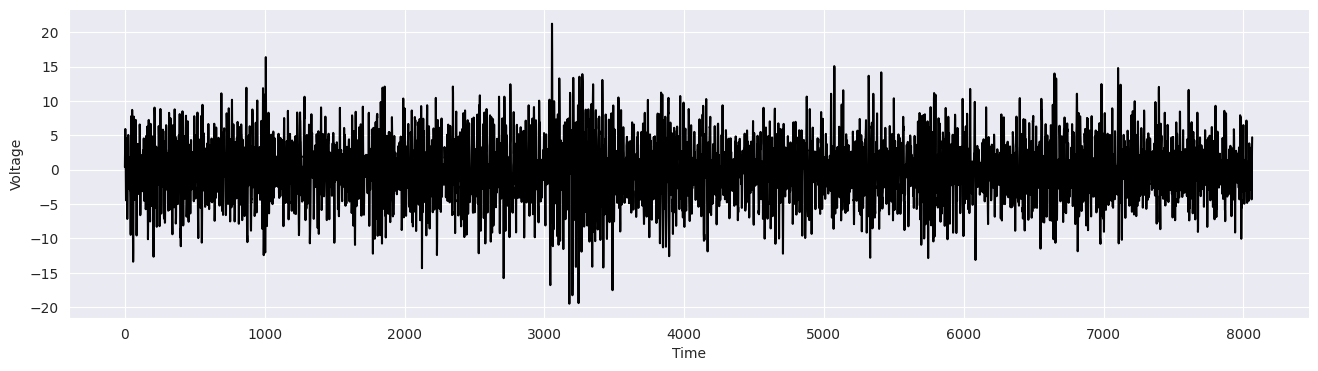

In [23]:
# Plot the signal of first trial, last channel 
fig, ax = plt.subplots(1, 1, figsize=(16, 4))
plt.plot(eeg_data[0,31], lw=1.5, color='k')
plt.xlabel('Time')
plt.ylabel('Voltage')
sns.despine()

In [24]:
info = mne.create_info(32, sfreq=128)
print(info)

<Info | 7 non-empty values
 bads: []
 ch_names: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, ...
 chs: 32 misc
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 64.0 Hz
 meas_date: unspecified
 nchan: 32
 projs: []
 sfreq: 128.0 Hz
>


In [25]:
info = mne.create_info(eeg_channels.tolist(), ch_types=32*['eeg'], sfreq=128)
info.set_montage('standard_1020')
print(info)

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, AF3, F3, F7, FC5, FC1, C3, T7, CP5, CP1, P3, P7, PO3, O1, ...
 chs: 32 EEG
 custom_ref_applied: False
 dig: 35 items (3 Cardinal, 32 EEG)
 highpass: 0.0 Hz
 lowpass: 64.0 Hz
 meas_date: unspecified
 nchan: 32
 projs: []
 sfreq: 128.0 Hz
>


In [26]:
raw_data = mne.io.RawArray(eeg_data[31], info)

Creating RawArray with float64 data, n_channels=32, n_times=8064
    Range : 0 ... 8063 =      0.000 ...    62.992 secs
Ready.


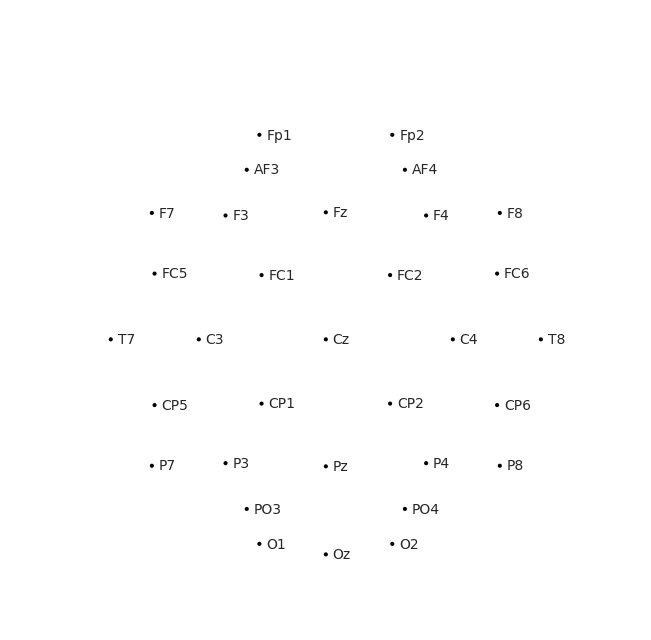

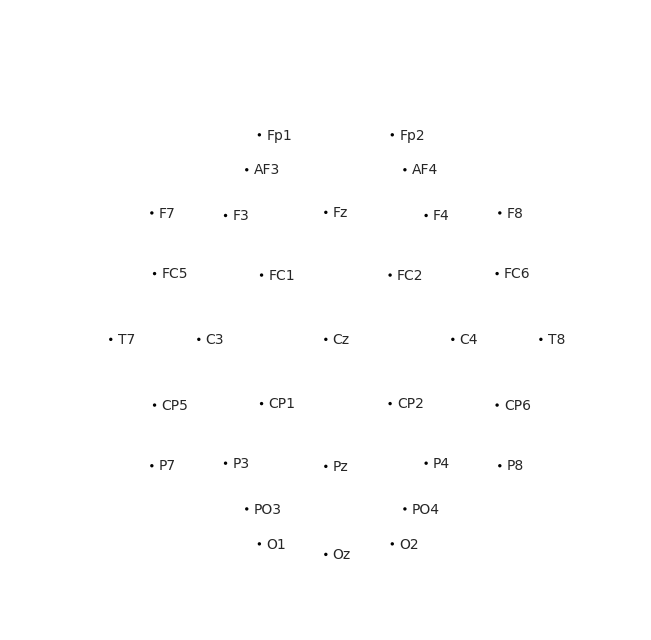

In [27]:
montage = mne.channels.make_standard_montage("biosemi32")
raw_data.set_montage(montage)
montage.plot()

NOTE: plot_raw_psd() is a legacy function. New code should use Raw.compute_psd().plot().
Effective window size : 16.000 (s)


/home/mehul/Desktop/Coding/BCI/venv/lib/python3.10/site-packages/mne/viz/utils.py:165: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


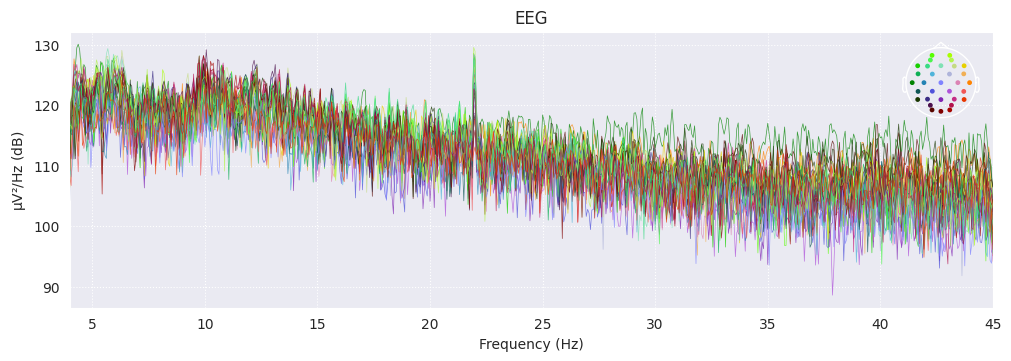

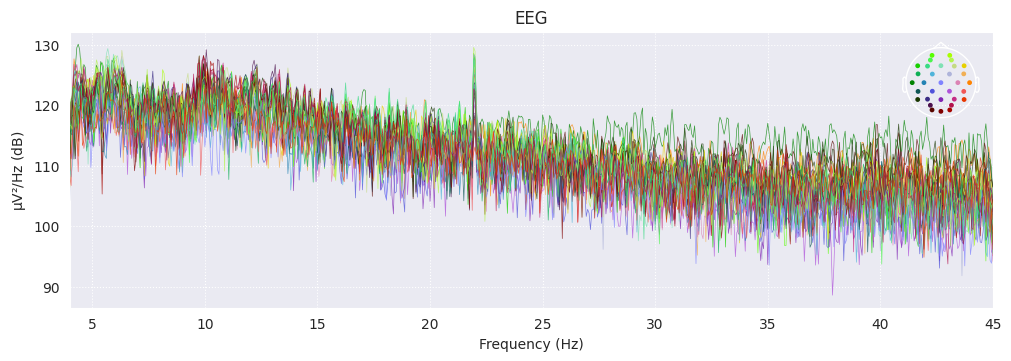

In [28]:
# Plot the power spectral density across channels
mne.viz.plot_raw_psd(raw_data, fmin = 4, fmax= 45)